# Transcriptions: one interval of a horizon, five ways

An optimal-control horizon is a chain of intervals, and a transcription decides what one interval
becomes: which variables it adds, which equality residuals tie its end to its start, and how it
integrates the running cost. `scaly.mpc` builds its horizons from exactly this contract, the
`sc.ocp.Interval`. This notebook uses the contract on its own, without MPC: five transcriptions of one
interval of a driven pendulum, each solved by Newton's method for its end state at a constant
control, and checked against `solve_ivp`. Collocation turns out to be an implicit Runge-Kutta method
in disguise, and pseudospectral collocation converges faster than any fixed order.

| Scaly feature | Where |
| --- | --- |
| `Transcription.interval(model, cost, dt=None)` | The interval contract |
| `sc.ocp.MultipleShooting` with `si.rk4` and with `si.implicit` | The interval contract |
| `sc.ocp.Collocation` at Radau and Gauss points, `sc.ocp.Pseudospectral` | The interval contract, Convergence |
| `Interval.fn`, `n_internal`, `n_residual`, `state_times`, `control_times`, `has_cost`, `guess` | The interval contract, Newton on one interval |
| `sc.jacobian` of the residuals | Newton on one interval |
| `si.implicit` Radau IIA and Gauss-Legendre | Collocation is an implicit Runge-Kutta method |
| `scaly.integrators.polynomial.interpolation_matrix` | Convergence |
| `write_module` | The generated C |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly.codegen import write_module
from scaly.integrators.polynomial import interpolation_matrix

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "integrators" / "transcriptions"

## The interval contract

The model is a damped pendulum driven by a torque, with the state $x = (\theta, \dot\theta)$ and the
running cost $\ell(x, u) = x^\top x + u^2$:

$$
\ddot\theta = -\frac{g}{L} \sin\theta - b\,\dot\theta + u, \qquad g/L = 9.81,\ b = 0.1 .
$$

`transcription.interval(model, cost, dt=...)` returns an `Interval` whose Function is

$$
\texttt{interval.fn}(x, u, [z], x^+, [h]) \to (r, \text{cost}),
$$

with $x$ and $x^+$ the states at the interval's ends, $u$ the control at its start, $z$ its own
`n_internal` variables (states at `state_times`, then controls at `control_times`, as fractions of
the interval), $h$ its length when `dt=None`, and $r$ its `n_residual` residuals. In the five
transcriptions below, with $\tau \in [0, 1]$ the time within the interval:

* Multiple shooting: $r = \Phi_h(x, u) - x^+$ with $\Phi_h$ the integrator's map (two RK4 steps,
  or one Radau IIA(2) step with three Newton iterations inside), and no $z$. The cost is integrated by
  the same map as one more state, $\dot q = \ell$.
* Collocation of degree $d$: a polynomial $p(\tau) = \sum_j \ell_j(\tau)\, x_j$ through $x_0 = x$
  and the states $x_1, \dots, x_d$ at the collocation points $\tau_1, \dots, \tau_d$, its derivative
  matched to the model there, $\sum_j D_{ij} x_j - h f(x_i, u) = 0$. At the right Radau points
  $\tau_d = 1$, so $x_d = x^+$; at the Gauss points one more residual $x^+ - p(1)$ closes the
  interval. The cost is the quadrature $h \sum_i w_i\, \ell(x_i, u)$.
* Pseudospectral collocation with $N$ nodes: collocation at $N$ Legendre-Gauss-Radau points that include
  0 and not 1, with the end $x^+$ as a node, and a control at every point; the one at 0 is $u$.

Every interval here is built with `dt=None`, so its length is an input and one compiled Function
per transcription serves every step size below.

In [2]:
G_L, DAMPING = 9.81, 0.1
NX, NU = 2, 1


@sc.function(NX, NU, output="xdot")
def tr_pendulum(x, u):
  return sc.stack([x[1], -G_L * x[0].sin() - DAMPING * x[1] + u[0]])


@sc.function(NX, NU, output="l")
def tr_effort(x, u):
  return (x * x).sum() + u[0] * u[0]


TRANSCRIPTIONS = {
  "shooting rk4 x2": sc.ocp.MultipleShooting(si.RK4(steps=2)),
  "shooting radau_iia2": sc.ocp.MultipleShooting(si.RadauIIA(2)),
  "collocation radau 3": sc.ocp.Collocation(3),
  "collocation legendre 2": sc.ocp.Collocation(2, "legendre"),
  "pseudospectral 8": sc.ocp.Pseudospectral(8),
}
INTERVALS = {key: t.interval(tr_pendulum, tr_effort, dt=None) for key, t in TRANSCRIPTIONS.items()}
print(f"{'transcription':24s} {'n_internal':>10s} {'n_residual':>10s} {'has_cost':>8s}  inputs of interval.fn")
for key, interval in INTERVALS.items():
  print(f"{key:24s} {interval.n_internal:10d} {interval.n_residual:10d} {interval.has_cost!s:>8s}  {', '.join(interval.fn.input_names)}")

transcription            n_internal n_residual has_cost  inputs of interval.fn
shooting rk4 x2                   0          2     True  x, u, xnext, dt
shooting radau_iia2               0          2     True  x, u, xnext, dt
collocation radau 3               4          6     True  x, u, z, xnext, dt
collocation legendre 2            4          6     True  x, u, z, xnext, dt
pseudospectral 8                 21         16     True  x, u, z, xnext, dt


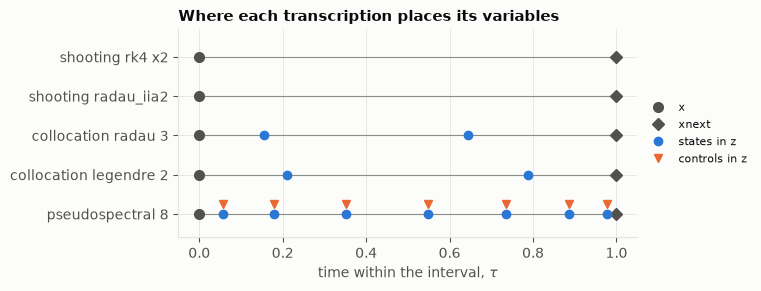

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 2.8))
for row, (key, interval) in enumerate(INTERVALS.items()):
  y = len(INTERVALS) - 1 - row
  ax.plot([0, 1], [y, y], color=plotstyle.NEUTRAL, lw=0.8)
  ax.plot([0], [y], "o", color=plotstyle.TEXT_SECONDARY, ms=7, label="x" if row == 0 else None)
  ax.plot([1], [y], "D", color=plotstyle.TEXT_SECONDARY, ms=6, label="xnext" if row == 0 else None)
  ax.plot(interval.state_times, [y] * interval.state_times.size, "o", color=plotstyle.BLUE, ms=6, label="states in z" if row == 2 else None)
  ax.plot(
    interval.control_times, [y + 0.25] * interval.control_times.size, "v", color=plotstyle.ORANGE, ms=6, label="controls in z" if row == 4 else None
  )
ax.set_yticks(range(len(INTERVALS)), list(INTERVALS)[::-1])
ax.set_ylim(-0.6, len(INTERVALS) - 0.3)
ax.set_xlabel(r"time within the interval, $\tau$")
ax.set_title("Where each transcription places its variables")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.show()

Shooting adds no variables: its two residuals are the map's end minus $x^+$. Radau collocation of
degree 3 adds the states at its two interior points, 0.155 and 0.645 (the third point is 1, whose
state is $x^+$), and has $3 \times 2$ residuals. Gauss collocation of degree 2 adds the states at its
two points, 0.211 and 0.789, and has $2 \times 2$ collocation residuals and 2 for continuity at 1.
Pseudospectral collocation with 8 nodes adds the states and the controls at its seven points
after 0, $7 \times 2 + 7 = 21$ variables, clustered towards the end of the interval.

## Newton on one interval

For each transcription, one more Function returns the residuals, the cost and `sc.jacobian` of the
residuals in the unknowns $v = (\text{states in } z,\ x^+)$, with the controls in $z$ held at $u$:

$$
v_{k+1} = v_k - \Big(\frac{\partial r}{\partial v}(v_k)\Big)^{-1} r(v_k),
$$

from `interval.guess(x, u)`, which puts every state at $x$ and every control at $u$, and from
$x^+ = x$, until $\lVert r \rVert_\infty < 10^{-13}$. The Jacobian is square: shooting has 2 unknowns
and 2 residuals, Radau collocation $2 + 4$ and 6, Gauss collocation $4 + 2$ and 6, pseudospectral
$14 + 2$ and 16. One interval of $h = 0.1$ from $x = (1, 0)$ at $u = 0.5$ is compared with
`solve_ivp` (DOP853 at `rtol=1e-13`) on the model augmented by $\dot q = \ell$.

In [4]:
X0, U0, DT = np.array([1.0, 0.0]), np.array([0.5]), 0.1
NEWTON_TOL, NEWTON_MAX = 1e-13, 20


def newton_system(interval):
  """(x, u, v, dt) -> (r, cost, dr/dv) with the unknowns v = (states in z, xnext), the controls in z held at u."""
  n_states, n_controls = interval.state_times.size * NX, interval.control_times.size

  @sc.function(NX, NU, n_states + NX, (), output=sc.G("r", "cost", "jac_r_v"), name=f"{interval.fn.name}_newton")
  def system(x, u, v, dt):
    z = [sc.concat([v[:n_states], *([u] * n_controls)])] if interval.n_internal else []
    r, cost = interval.fn(x, u, *z, v[n_states:], dt)
    return r, cost, sc.jacobian(r, v)

  return system


SYSTEMS = {key: newton_system(interval) for key, interval in INTERVALS.items()}


def solve_interval(interval, system, x, u, dt):
  """(v, cost, iterations): Newton's method on the interval's residuals from interval.guess."""
  n_states = interval.state_times.size * NX
  v = np.concatenate([interval.guess(x, u)[:n_states], x])
  for iteration in range(NEWTON_MAX):
    r, cost, jac = system(x, u, v, np.array(dt))
    if np.abs(r).max() < NEWTON_TOL:
      return v, float(cost[0]), iteration
    v = v - np.linalg.solve(jac, r)
  raise RuntimeError(f"Newton on {interval.fn.name} did not converge")


def reference(x, u, span, t_eval=None):
  """(x(span), integral of l) by DOP853 on the model augmented by q' = l; all of t_eval when given."""

  def rhs(t, y):
    return [y[1], -G_L * np.sin(y[0]) - DAMPING * y[1] + u[0], y[0] ** 2 + y[1] ** 2 + u[0] ** 2]

  sol = solve_ivp(rhs, (0, span), [*x, 0.0], method="DOP853", rtol=1e-13, atol=1e-14, t_eval=t_eval)
  return sol.y if t_eval is not None else sol.y[:, -1]


exact = reference(X0, U0, DT)
table = {}
for key, interval in INTERVALS.items():
  v, cost, iterations = solve_interval(interval, SYSTEMS[key], X0, U0, DT)
  table[key] = {
    "xnext": v[-NX:],
    "xnext_error": float(np.abs(v[-NX:] - exact[:NX]).max()),
    "cost_error": float(abs(cost - exact[NX]) / exact[NX]),
    "newton_iterations": iterations,
  }
print(f"solve_ivp: xnext = {exact[:NX].round(6)}, cost = {exact[NX]:.6f}")
print(f"{'transcription':24s} {'Newton':>6s} {'xnext error':>12s} {'cost error':>11s}")
for key, row in table.items():
  print(f"{key:24s} {row['newton_iterations']:6d} {row['xnext_error']:12.1e} {row['cost_error']:11.1e}")

solve_ivp: xnext = [ 0.961527 -0.764699], cost = 0.142142
transcription            Newton  xnext error  cost error
shooting rk4 x2               1      3.0e-06     2.4e-05
shooting radau_iia2           1      8.6e-05     3.6e-04
collocation radau 3           3      1.3e-07     1.7e-06
collocation legendre 2        3      9.2e-07     8.3e-05
pseudospectral 8              3      2.1e-15     1.5e-13


Shooting needs one Newton step, since its residual is linear in $x^+$; the collocation systems need
three. Over this short interval the errors follow the orders: $3.0 \times 10^{-6}$ for two RK4 steps,
$8.6 \times 10^{-5}$ for one Radau IIA(2) step (order 3), $1.3 \times 10^{-7}$ for Radau collocation
of degree 3 (order 5), $9.2 \times 10^{-7}$ for Gauss collocation of degree 2 (order 4), and
$2 \times 10^{-15}$ for pseudospectral collocation with 8 nodes. The cost over the interval is
0.142; its relative errors range from $1.7 \times 10^{-6}$ (Radau collocation) to
$3.6 \times 10^{-4}$ (Radau IIA(2) shooting), and $1.5 \times 10^{-13}$ for pseudospectral
collocation.

## Collocation is an implicit Runge-Kutta method

At a constant control, the collocation conditions at points $\tau_1, \dots, \tau_d$ are the stage
equations of the Runge-Kutta method with $a_{ij} = \int_0^{\tau_i} \ell_j$ and
$b_j = \int_0^1 \ell_j$, the stages being the polynomial's slopes at the points. At the Radau points
that method is Radau IIA($d$), at the Gauss points Gauss-Legendre($d$), so the solved $x^+$ must
equal `si.implicit`'s step to rounding.

In [5]:
RADAU3 = si.implicit(tr_pendulum, "radau_iia", stages=3, dt=DT, tol=1e-14, max_iter=50)
GAUSS2 = si.implicit(tr_pendulum, "gauss_legendre", stages=2, dt=DT, tol=1e-14, max_iter=50)


@sc.function(NX, NU, output=sc.G("radau", "gauss"))
def tr_implicit_steps(x, u):
  return RADAU3(x, u), GAUSS2(x, u)


radau, gauss = tr_implicit_steps(X0, U0)
radau_equivalence = float(np.abs(table["collocation radau 3"]["xnext"] - radau).max())
legendre_equivalence = float(np.abs(table["collocation legendre 2"]["xnext"] - gauss).max())
print(f"collocation radau 3 against si.implicit radau_iia3:          {radau_equivalence:.1e}")
print(f"collocation legendre 2 against si.implicit gauss_legendre2:  {legendre_equivalence:.1e}")

collocation radau 3 against si.implicit radau_iia3:          1.1e-16
collocation legendre 2 against si.implicit gauss_legendre2:  1.1e-16


Both agree to $1.1 \times 10^{-16}$, one unit in the last place. The two computations share nothing
but the nodes: one solves the interval's residuals with NumPy's Newton iteration above, the other
runs Newton's method inside the generated step.

## Convergence

Chaining $n$ intervals of $h = T/n$ over $T = 2$ from $x = (1, 0)$, each solved in turn, the error
at the end falls as $h^{2d - 1}$ for Radau collocation and as $h^{2d}$ for Gauss collocation. A
single pseudospectral interval over the whole of $T$ converges instead in the number of nodes $N$,
and for a smooth solution faster than any power of $N$.

In [6]:
T = 2.0
INTERVAL_COUNTS = (8, 16, 32, 64)
NODE_COUNTS = (4, 8, 12, 16)
PS_SWEEP = {n: INTERVALS["pseudospectral 8"] if n == 8 else sc.ocp.Pseudospectral(n).interval(tr_pendulum, tr_effort, dt=None) for n in NODE_COUNTS}
PS_SYSTEMS = {n: SYSTEMS["pseudospectral 8"] if n == 8 else newton_system(interval) for n, interval in PS_SWEEP.items()}


def chained(key, count):
  """The end of count intervals of length T / count from X0, each solved in turn."""
  x = X0
  for _ in range(count):
    x = solve_interval(INTERVALS[key], SYSTEMS[key], x, U0, T / count)[0][-NX:]
  return x


def slope(counts, errors):
  """The least-squares slope of log error against log count over the three finest counts."""
  return float(-np.polyfit(np.log(counts[-3:]), np.log(errors[-3:]), 1)[0])


end = reference(X0, U0, T)[:NX]
radau_errors = np.array([np.abs(chained("collocation radau 3", n) - end).max() for n in INTERVAL_COUNTS])
legendre_errors = np.array([np.abs(chained("collocation legendre 2", n) - end).max() for n in INTERVAL_COUNTS])
radau_order, legendre_order = slope(INTERVAL_COUNTS, radau_errors), slope(INTERVAL_COUNTS, legendre_errors)
ps_solutions = {n: solve_interval(PS_SWEEP[n], PS_SYSTEMS[n], X0, U0, T)[0] for n in NODE_COUNTS}
ps_errors = np.array([np.abs(ps_solutions[n][-NX:] - end).max() for n in NODE_COUNTS])
ps_local_orders = np.log(ps_errors[:-1] / ps_errors[1:]) / np.log(np.array(NODE_COUNTS[1:]) / NODE_COUNTS[:-1])
print(f"{'intervals':24s} " + " ".join(f"{n:8d}" for n in INTERVAL_COUNTS) + "   order")
print(f"{'collocation radau 3':24s} " + " ".join(f"{e:8.1e}" for e in radau_errors) + f"   {radau_order:.2f}")
print(f"{'collocation legendre 2':24s} " + " ".join(f"{e:8.1e}" for e in legendre_errors) + f"   {legendre_order:.2f}")
print(f"{'nodes':24s} " + " ".join(f"{n:8d}" for n in NODE_COUNTS))
print(f"{'pseudospectral':24s} " + " ".join(f"{e:8.1e}" for e in ps_errors))
print(f"{'order between counts':24s} " + " ".join(f"{o:8.1f}" for o in ps_local_orders))

intervals                       8       16       32       64   order
collocation radau 3       2.0e-04  7.3e-06  2.5e-07  7.9e-09   4.92
collocation legendre 2    5.0e-03  3.2e-04  2.0e-05  1.3e-06   4.00
nodes                           4        8       12       16
pseudospectral            9.6e-01  4.2e-03  3.5e-05  9.4e-08
order between counts          7.8     11.8     20.6


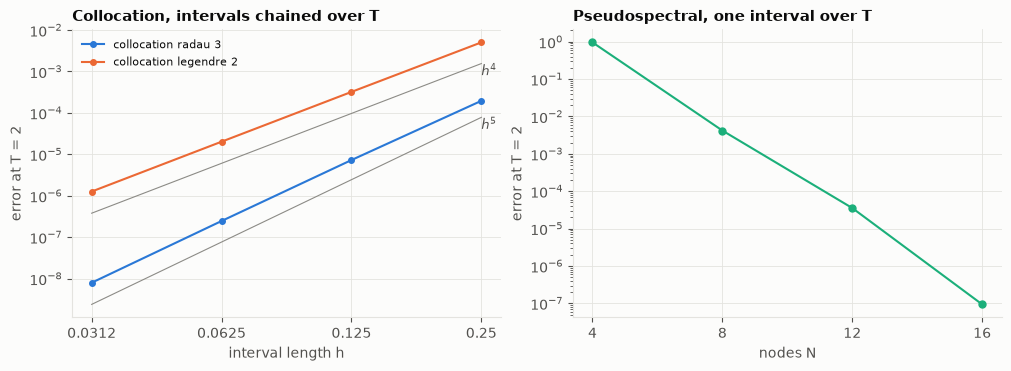

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
h = T / np.array(INTERVAL_COUNTS)
for errors, p, name, color in (
  (radau_errors, 5, "collocation radau 3", plotstyle.BLUE),
  (legendre_errors, 4, "collocation legendre 2", plotstyle.ORANGE),
):
  ax1.loglog(h, errors, "o-", color=color, ms=4, lw=1.5, label=name)
  ax1.loglog(h, 0.3 * errors[-1] * (h / h[-1]) ** p, color=plotstyle.NEUTRAL, lw=0.8)
  ax1.annotate(f"$h^{p}$", (h[0], 0.3 * errors[-1] * (h[0] / h[-1]) ** p), color=plotstyle.TEXT_SECONDARY, fontsize=9, va="top")
ax1.set_xticks(h, [f"{v:.3g}" for v in h])
ax1.minorticks_off()
ax1.set_xlabel("interval length h")
ax1.set_ylabel("error at T = 2")
ax1.set_title("Collocation, intervals chained over T")
ax1.legend(fontsize=8)
ax2.semilogy(NODE_COUNTS, ps_errors, "o-", color=plotstyle.AQUA, ms=5, lw=1.5)
ax2.set_xticks(NODE_COUNTS)
ax2.set_xlabel("nodes N")
ax2.set_ylabel("error at T = 2")
ax2.set_title("Pseudospectral, one interval over T")
plt.show()

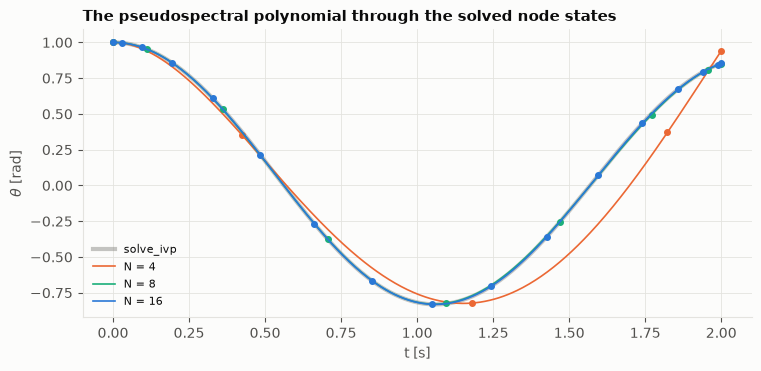

In [8]:
t_fine = np.linspace(0, T, 400)
theta_ref = reference(X0, U0, T, t_eval=t_fine)[0]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(t_fine, theta_ref, color=plotstyle.NEUTRAL, lw=3, alpha=0.5, label="solve_ivp")
for n, color in zip((4, 8, 16), (plotstyle.ORANGE, plotstyle.AQUA, plotstyle.BLUE), strict=True):
  interval, v = PS_SWEEP[n], ps_solutions[n]
  nodes = np.concatenate([[0.0], interval.state_times, [1.0]])
  thetas = np.concatenate([[X0[0]], v[:-NX:NX], [v[-NX]]])  # theta at every node: x, the states in z, xnext
  ax.plot(t_fine, interpolation_matrix(nodes, t_fine / T) @ thetas, color=color, lw=1.2, label=f"N = {n}")
  ax.plot(T * nodes, thetas, "o", color=color, ms=4)
ax.set_xlabel("t [s]")
ax.set_ylabel(r"$\theta$ [rad]")
ax.set_title("The pseudospectral polynomial through the solved node states")
ax.legend(fontsize=8)
plt.show()

Over the three finest counts the slopes are 4.92 for Radau collocation of degree 3 and 4.00 for
Gauss collocation of degree 2, the orders $2d - 1 = 5$ and $2d = 4$; at 64 intervals the errors are
$7.9 \times 10^{-9}$ and $1.3 \times 10^{-6}$. The pseudospectral error falls from 0.96 at 4 nodes to
$9.4 \times 10^{-8}$ at 16, close to a straight line on the semi-log axes. Between 4 and 8, 8 and
12, 12 and 16 nodes it falls as $N^{-8}$, $N^{-12}$ and $N^{-21}$, an effective order that keeps
growing. With 4 nodes the polynomial cannot bend enough to follow one swing of the pendulum; with 8
it is close, and with 16 it lies on the reference.

## Checks

In [9]:
layout = {key: (i.n_internal, i.n_residual, i.state_times.size, i.control_times.size) for key, i in INTERVALS.items()}
assert layout == {
  "shooting rk4 x2": (0, 2, 0, 0),
  "shooting radau_iia2": (0, 2, 0, 0),
  "collocation radau 3": (4, 6, 2, 0),
  "collocation legendre 2": (4, 6, 2, 0),
  "pseudospectral 8": (21, 16, 7, 7),
}
assert all(i.has_cost for i in INTERVALS.values())
bounds = {
  "shooting rk4 x2": (3e-5, 3e-4),
  "shooting radau_iia2": (1e-3, 4e-3),
  "collocation radau 3": (1.3e-6, 2e-5),
  "collocation legendre 2": (1e-5, 1e-3),
  "pseudospectral 8": (1e-13, 2e-12),
}
for key, (x_bound, cost_bound) in bounds.items():
  assert table[key]["xnext_error"] < x_bound and table[key]["cost_error"] < cost_bound, key
  assert table[key]["newton_iterations"] <= (1 if key.startswith("shooting") else 5), key
assert radau_equivalence < 1e-12 and legendre_equivalence < 1e-12
assert abs(radau_order - 5) < 0.3 and abs(legendre_order - 4) < 0.3
assert ps_errors[-1] < 1e-6 and np.all(np.diff(ps_local_orders) > 0) and ps_local_orders[-1] > 12
print("all 7 checks passed")

all 7 checks passed


## The generated C

The interval Function of Radau collocation of degree 3, with its length an input: three calls of
the model, the collocation residuals with the differentiation matrix folded in as constants, and
the quadrature of the cost.

In [10]:
module = write_module(INTERVALS["collocation radau 3"].fn, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.1f} kB")
lines = module.source.splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith("int tr_pendulum_collocation_radau3("))
stop = next(i for i in range(start, len(lines)) if lines[i] == "}")
print("\n".join(lines[start : stop + 1]))

tr_pendulum_collocation_radau3.c: 70 lines, 2.6 kB
int tr_pendulum_collocation_radau3(const double** arg, double** res, int* iw, double* w, int mem) {
  (void)iw;
  (void)mem;
  if (!arg || !res) return SCALY_ERR_NULL_ABI;
  (void)w;
  if (!arg[0]) return SCALY_ERR_NULL_INPUT;
  if (!arg[1]) return SCALY_ERR_NULL_INPUT;
  if (!arg[2]) return SCALY_ERR_NULL_INPUT;
  if (!arg[3]) return SCALY_ERR_NULL_INPUT;
  if (!arg[4]) return SCALY_ERR_NULL_INPUT;
  if (!res[0]) return SCALY_ERR_NULL_RESULT;
  if (!res[1]) return SCALY_ERR_NULL_RESULT;
  const double* t3 = arg[2];
  const double* t7 = arg[2] + 2;
  double s0[2];
  double s1[2];
  double s2[2];
  tr_pendulum_raw(t3, arg[1], s0, NULL);
  tr_pendulum_raw(t7, arg[1], s1, NULL);
  tr_pendulum_raw(arg[3], arg[1], s2, NULL);
  for (long long j_r_0 = 0; j_r_0 < 2; ++j_r_0) {
    res[0][j_r_0] = (((((-4.1393876913398122 * arg[0][j_r_0]) + (3.2247448713915872 * t3[j_r_0])) + (1.1678400846904058 * t7[j_r_0])) + (-0.25319726474218079 * arg[3][j_